# Pitch-Line Segmentation for Camera Calibration

**Goal:** Train a DeepLabV3+ model to segment each pitch line/circle as a distinct class,
then use dense 2D↔3D correspondences (hundreds per frame) to solve the homography.

**Why segmentation beats sparse keypoints:**
- The center circle has only 3 keypoints (center mark + 2 halfway-line intersections) — too few for a good homography when the penalty area is out of view.
- A segmentation model detects the full circle as ~50–80 pixel samples, each mapped to the known 3D geometry.
- Every visible line contributes correspondences proportional to its pixel length.

**Pipeline:**
1. **Cell 1–2:** Install dependencies + define `SoccerPitch` / `Camera` classes
2. **Cell 3–5:** Download SoccerNet, WorldCup 2014, TS-WorldCup datasets
3. **Cell 6–7:** Build segmentation dataset (24 classes: background + 23 line classes)
4. **Cell 8:** Visual verification
5. **Cell 9:** Train DeepLabV3+ (ResNet-50)
6. **Cell 10:** Video inference with dense correspondence matching

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "SoccerNet", "opencv-python-headless",
                       "matplotlib", "Pillow",
                       "segmentation-models-pytorch", "albumentations",
                       "torch", "torchvision"])


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

In [3]:
import numpy as np
import cv2

class SoccerPitch:
    """FIFA soccer pitch 3D model with all keypoints and line definitions.
    
    Coordinate system (meters from pitch center):
        X: pitch length axis  (- = left goal, + = right goal)
        Y: pitch width axis   (- = top touchline, + = bottom touchline)
        Z: height             (0 = ground)
    """
    PITCH_LENGTH = 105.0
    PITCH_WIDTH = 68.0
    PENALTY_AREA_LENGTH = 16.5
    PENALTY_AREA_WIDTH = 40.32
    GOAL_AREA_LENGTH = 5.5
    GOAL_AREA_WIDTH = 18.32
    CENTER_CIRCLE_RADIUS = 9.15
    GOAL_HEIGHT = 2.44
    GOAL_LENGTH = 7.32
    GOAL_LINE_TO_PENALTY_MARK = 11.0

    def __init__(self, pitch_length=105., pitch_width=68.):
        L = pitch_length / 2
        W = pitch_width / 2
        PA_L = self.PENALTY_AREA_LENGTH
        PA_HW = self.PENALTY_AREA_WIDTH / 2
        GA_L = self.GOAL_AREA_LENGTH
        GA_HW = self.GOAL_AREA_WIDTH / 2
        R = self.CENTER_CIRCLE_RADIUS
        GH = self.GOAL_HEIGHT
        GL_H = self.GOAL_LENGTH / 2
        PM = self.GOAL_LINE_TO_PENALTY_MARK

        dx = PA_L - PM
        arc_dy = np.sqrt(R**2 - dx**2)

        self.point_dict = {
            "TL_PITCH_CORNER": np.array([-L, -W, 0.]),
            "TR_PITCH_CORNER": np.array([ L, -W, 0.]),
            "BL_PITCH_CORNER": np.array([-L,  W, 0.]),
            "BR_PITCH_CORNER": np.array([ L,  W, 0.]),
            "T_TOUCH_AND_HALFWAY_LINES_INTERSECTION": np.array([0., -W, 0.]),
            "B_TOUCH_AND_HALFWAY_LINES_INTERSECTION": np.array([0.,  W, 0.]),
            "CENTER_MARK": np.array([0., 0., 0.]),
            "T_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION": np.array([0., -R, 0.]),
            "B_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION": np.array([0.,  R, 0.]),
            "L_PENALTY_MARK": np.array([-L + PM, 0., 0.]),
            "R_PENALTY_MARK": np.array([ L - PM, 0., 0.]),
            "L_PENALTY_AREA_TL_CORNER": np.array([-L,        -PA_HW, 0.]),
            "L_PENALTY_AREA_TR_CORNER": np.array([-L + PA_L, -PA_HW, 0.]),
            "L_PENALTY_AREA_BL_CORNER": np.array([-L,         PA_HW, 0.]),
            "L_PENALTY_AREA_BR_CORNER": np.array([-L + PA_L,  PA_HW, 0.]),
            "R_PENALTY_AREA_TL_CORNER": np.array([ L - PA_L, -PA_HW, 0.]),
            "R_PENALTY_AREA_TR_CORNER": np.array([ L,        -PA_HW, 0.]),
            "R_PENALTY_AREA_BL_CORNER": np.array([ L - PA_L,  PA_HW, 0.]),
            "R_PENALTY_AREA_BR_CORNER": np.array([ L,         PA_HW, 0.]),
            "L_GOAL_AREA_TL_CORNER": np.array([-L,        -GA_HW, 0.]),
            "L_GOAL_AREA_TR_CORNER": np.array([-L + GA_L, -GA_HW, 0.]),
            "L_GOAL_AREA_BL_CORNER": np.array([-L,         GA_HW, 0.]),
            "L_GOAL_AREA_BR_CORNER": np.array([-L + GA_L,  GA_HW, 0.]),
            "R_GOAL_AREA_TL_CORNER": np.array([ L - GA_L, -GA_HW, 0.]),
            "R_GOAL_AREA_TR_CORNER": np.array([ L,        -GA_HW, 0.]),
            "R_GOAL_AREA_BL_CORNER": np.array([ L - GA_L,  GA_HW, 0.]),
            "R_GOAL_AREA_BR_CORNER": np.array([ L,         GA_HW, 0.]),
            "L_GOAL_BL_POST": np.array([-L,  GL_H,  0.]),
            "L_GOAL_TL_POST": np.array([-L,  GL_H, -GH]),
            "L_GOAL_BR_POST": np.array([-L, -GL_H,  0.]),
            "L_GOAL_TR_POST": np.array([-L, -GL_H, -GH]),
            "R_GOAL_BL_POST": np.array([ L, -GL_H,  0.]),
            "R_GOAL_TL_POST": np.array([ L, -GL_H, -GH]),
            "R_GOAL_BR_POST": np.array([ L,  GL_H,  0.]),
            "R_GOAL_TR_POST": np.array([ L,  GL_H, -GH]),
            "TL_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([-L + PA_L, -arc_dy, 0.]),
            "BL_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([-L + PA_L,  arc_dy, 0.]),
            "TR_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([ L - PA_L, -arc_dy, 0.]),
            "BR_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([ L - PA_L,  arc_dy, 0.]),
        }

        p = self.point_dict
        self.line_extremities = {
            "Side line top":           (p["TL_PITCH_CORNER"], p["TR_PITCH_CORNER"]),
            "Side line bottom":        (p["BL_PITCH_CORNER"], p["BR_PITCH_CORNER"]),
            "Side line left":          (p["TL_PITCH_CORNER"], p["BL_PITCH_CORNER"]),
            "Side line right":         (p["TR_PITCH_CORNER"], p["BR_PITCH_CORNER"]),
            "Middle line":             (p["T_TOUCH_AND_HALFWAY_LINES_INTERSECTION"],
                                        p["B_TOUCH_AND_HALFWAY_LINES_INTERSECTION"]),
            "Big rect. left top":      (p["L_PENALTY_AREA_TL_CORNER"], p["L_PENALTY_AREA_TR_CORNER"]),
            "Big rect. left bottom":   (p["L_PENALTY_AREA_BL_CORNER"], p["L_PENALTY_AREA_BR_CORNER"]),
            "Big rect. left main":     (p["L_PENALTY_AREA_TR_CORNER"], p["L_PENALTY_AREA_BR_CORNER"]),
            "Big rect. right top":     (p["R_PENALTY_AREA_TL_CORNER"], p["R_PENALTY_AREA_TR_CORNER"]),
            "Big rect. right bottom":  (p["R_PENALTY_AREA_BL_CORNER"], p["R_PENALTY_AREA_BR_CORNER"]),
            "Big rect. right main":    (p["R_PENALTY_AREA_TL_CORNER"], p["R_PENALTY_AREA_BL_CORNER"]),
            "Small rect. left top":    (p["L_GOAL_AREA_TL_CORNER"], p["L_GOAL_AREA_TR_CORNER"]),
            "Small rect. left bottom": (p["L_GOAL_AREA_BL_CORNER"], p["L_GOAL_AREA_BR_CORNER"]),
            "Small rect. left main":   (p["L_GOAL_AREA_TR_CORNER"], p["L_GOAL_AREA_BR_CORNER"]),
            "Small rect. right top":   (p["R_GOAL_AREA_TL_CORNER"], p["R_GOAL_AREA_TR_CORNER"]),
            "Small rect. right bottom":(p["R_GOAL_AREA_BL_CORNER"], p["R_GOAL_AREA_BR_CORNER"]),
            "Small rect. right main":  (p["R_GOAL_AREA_TL_CORNER"], p["R_GOAL_AREA_BL_CORNER"]),
            "Goal left crossbar":      (p["L_GOAL_TR_POST"], p["L_GOAL_TL_POST"]),
            "Goal left post left ":    (p["L_GOAL_TL_POST"], p["L_GOAL_BL_POST"]),
            "Goal left post right":    (p["L_GOAL_TR_POST"], p["L_GOAL_BR_POST"]),
            "Goal right crossbar":     (p["R_GOAL_TL_POST"], p["R_GOAL_TR_POST"]),
            "Goal right post left":    (p["R_GOAL_TL_POST"], p["R_GOAL_BL_POST"]),
            "Goal right post right":   (p["R_GOAL_TR_POST"], p["R_GOAL_BR_POST"]),
            "Circle central":          (p["T_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION"],
                                        p["B_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION"]),
            "Circle left":             (p["TL_16M_LINE_AND_PENALTY_ARC_INTERSECTION"],
                                        p["BL_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]),
            "Circle right":            (p["TR_16M_LINE_AND_PENALTY_ARC_INTERSECTION"],
                                        p["BR_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]),
        }

    def sample_field_points(self, dist=0.5, dist_circles=0.3):
        polylines = {}
        R = self.CENTER_CIRCLE_RADIUS
        p = self.point_dict

        center = p["CENTER_MARK"]
        n = max(int(2 * np.pi * R / dist_circles), 36)
        angles = np.linspace(0, 2 * np.pi, n, endpoint=True)
        polylines["Circle central"] = [
            np.array([center[0] + R * np.cos(a), center[1] + R * np.sin(a), 0.])
            for a in angles
        ]

        for side in ["left", "right"]:
            prefix = "L" if side == "left" else "R"
            mark = p[f"{prefix}_PENALTY_MARK"]
            top = p[f"T{prefix}_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]
            bot = p[f"B{prefix}_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]

            a_top = np.arctan2(top[1] - mark[1], top[0] - mark[0])
            a_bot = np.arctan2(bot[1] - mark[1], bot[0] - mark[0])
            if side == "left":
                fromA, toA = a_top, a_bot
            else:
                fromA, toA = a_bot, a_top
            if toA < fromA:
                toA += 2 * np.pi
            n_arc = max(int(R * (toA - fromA) / dist_circles), 10)
            arc_angles = np.linspace(fromA, toA, n_arc)
            polylines[f"Circle {side}"] = [
                np.array([mark[0] + R * np.cos(a), mark[1] + R * np.sin(a), 0.])
                for a in arc_angles
            ]

        for key, (start, end) in self.line_extremities.items():
            if "Circle" in key:
                continue
            total = np.linalg.norm(end - start)
            n_seg = max(int(total / dist), 2)
            polylines[key] = [
                start + t * (end - start) for t in np.linspace(0, 1, n_seg)
            ]
        return polylines

    def get_ground_keypoints(self):
        return {k: v for k, v in self.point_dict.items() if v[2] == 0.}


class Camera:
    def __init__(self, iwidth=960, iheight=540):
        self.image_width = iwidth
        self.image_height = iheight
        self.position = np.zeros(3)
        self.rotation = np.eye(3)
        self.xfocal_length = 1.0
        self.yfocal_length = 1.0
        self.principal_point = (iwidth / 2, iheight / 2)
        self.calibration = np.eye(3)

    def from_homography(self, H):
        success, _ = self._estimate_calibration(H)
        if not success:
            return False
        hprim = np.linalg.inv(self.calibration) @ H
        lam1 = 1.0 / np.linalg.norm(hprim[:, 0])
        lam2 = 1.0 / np.linalg.norm(hprim[:, 1])
        lam3 = np.sqrt(lam1 * lam2)
        r0 = hprim[:, 0] * lam1
        r1 = hprim[:, 1] * lam2
        r2 = np.cross(r0, r1)
        R = np.column_stack((r0, r1, r2))
        u, s, vh = np.linalg.svd(R)
        R = u @ vh
        if np.linalg.det(R) < 0:
            u[:, 2] *= -1
            R = u @ vh
        self.rotation = R
        t = hprim[:, 2] * lam3
        self.position = -R.T @ t
        return True

    def _estimate_calibration(self, H):
        h = H.flatten()
        A = np.zeros((5, 6))
        A[0, 1] = 1.0
        A[1, 0] = 1.0
        A[1, 2] = -1.0
        A[2, 3] = self.principal_point[1] / self.principal_point[0]
        A[2, 4] = -1.0
        A[3] = [h[0]*h[1], h[0]*h[4]+h[1]*h[3], h[3]*h[4],
                h[0]*h[7]+h[1]*h[6], h[3]*h[7]+h[4]*h[6], h[6]*h[7]]
        A[4] = [h[0]**2-h[1]**2, 2*(h[0]*h[3]-h[1]*h[4]), h[3]**2-h[4]**2,
                2*(h[0]*h[6]-h[1]*h[7]), 2*(h[3]*h[6]-h[4]*h[7]), h[6]**2-h[7]**2]
        _, _, vh = np.linalg.svd(A)
        w = vh[-1]
        W = np.array([[w[0]/w[5], w[1]/w[5], w[3]/w[5]],
                      [w[1]/w[5], w[2]/w[5], w[4]/w[5]],
                      [w[3]/w[5], w[4]/w[5], 1.0]])
        try:
            Ktinv = np.linalg.cholesky(W)
        except np.linalg.LinAlgError:
            return False, np.eye(3)
        K = np.linalg.inv(Ktinv.T)
        K /= K[2, 2]
        self.xfocal_length = K[0, 0]
        self.yfocal_length = K[1, 1]
        self.principal_point = (self.image_width / 2, self.image_height / 2)
        self.calibration = np.array([
            [self.xfocal_length, 0, self.principal_point[0]],
            [0, self.yfocal_length, self.principal_point[1]],
            [0, 0, 1]
        ])
        return True, K

    def project_point(self, point3D):
        p = point3D - self.position
        rp = self.rotation @ p
        if rp[2] <= 1e-3:
            return np.zeros(3)
        rp = rp / rp[2]
        x = rp[0] * self.xfocal_length + self.principal_point[0]
        y = rp[1] * self.yfocal_length + self.principal_point[1]
        return np.array([x, y, 1.0])


print("SoccerPitch and Camera classes defined.")

SoccerPitch and Camera classes defined.


## Data Download
Download SoccerNet calibration-2023, WorldCup 2014, and TS-WorldCup datasets.

In [4]:
from SoccerNet.Downloader import SoccerNetDownloader

mySoccerNetDownloader = SoccerNetDownloader(LocalDirectory="./data/SoccerNet/CameraCalibration")
mySoccerNetDownloader.downloadDataTask(
    task="calibration-2023",
    split=["train", "valid", "test"]
)

./data/SoccerNet/CameraCalibration/calibration-2023/train.zip already exists
./data/SoccerNet/CameraCalibration/calibration-2023/valid.zip already exists
./data/SoccerNet/CameraCalibration/calibration-2023/test.zip already exists


In [5]:
import urllib.request, tarfile
from pathlib import Path

WC_DIR = Path("data/worldcup/raw")
WC_URL = "https://nhoma.github.io/data/soccer_data.tar.gz"
WC_TAR = Path("data/worldcup/soccer_data.tar.gz")

if not (WC_DIR / "train_val").exists():
    WC_TAR.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading WorldCup 2014 dataset...")
    urllib.request.urlretrieve(WC_URL, WC_TAR)
    WC_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting...")
    with tarfile.open(WC_TAR, "r:gz") as tar:
        tar.extractall(WC_DIR)
    extracted = [p for p in WC_DIR.iterdir() if p.name != WC_TAR.name]
    if len(extracted) == 1 and extracted[0].is_dir() and extracted[0].name != "train_val":
        for child in extracted[0].iterdir():
            child.rename(WC_DIR / child.name)
        extracted[0].rmdir()
    WC_TAR.unlink()
    print(f"Extracted to {WC_DIR}")
else:
    print(f"WorldCup 2014 already downloaded at {WC_DIR}")

n_train = len(list((WC_DIR / "train_val").glob("*.jpg")))
n_test = len(list((WC_DIR / "test").glob("*.jpg")))
print(f"  train_val: {n_train} images")
print(f"  test:      {n_test} images")

WorldCup 2014 already downloaded at data/worldcup/raw
  train_val: 209 images
  test:      186 images


In [6]:
import urllib.request, zipfile
from pathlib import Path

TSWC_DIR = Path("data/ts_worldcup")
TSWC_URL = "https://cgv.cs.nthu.edu.tw/KpSFR_data/TS-WorldCup.zip"
TSWC_ZIP = Path("data/ts_worldcup.zip")

if not (TSWC_DIR / "TS-WorldCup" / "train.txt").exists():
    TSWC_DIR.mkdir(parents=True, exist_ok=True)
    if not TSWC_ZIP.exists():
        print("Downloading TS-WorldCup dataset (~600 MB)...")
        urllib.request.urlretrieve(TSWC_URL, TSWC_ZIP)
    print("Extracting...")
    with zipfile.ZipFile(TSWC_ZIP) as zf:
        zf.extractall(TSWC_DIR)
    TSWC_ZIP.unlink()
    print(f"Extracted to {TSWC_DIR}")
else:
    print(f"TS-WorldCup already downloaded at {TSWC_DIR}")

tswc_root = TSWC_DIR / "TS-WorldCup"
train_clips = (tswc_root / "train.txt").read_text().strip().split("\n")
test_clips = (tswc_root / "test.txt").read_text().strip().split("\n")
n_imgs = len(list(tswc_root.rglob("*.jpg")))
print(f"  Total images: {n_imgs}")
print(f"  Train clips:  {len(train_clips)}")
print(f"  Test clips:   {len(test_clips)}")

TS-WorldCup already downloaded at data/ts_worldcup
  Total images: 3812
  Train clips:  33
  Test clips:   10


## Build Segmentation Dataset

For each image, render the pitch lines as a class-ID mask:
- **SoccerNet:** Use annotation polylines directly for straight lines, project circles via homography
- **WorldCup / TS-WorldCup:** Project the full 3D pitch model through the homography matrix

Output: `datasets/pitch_seg/{images,masks}/{train,val,test}/`

In [8]:
"""
Build semantic-segmentation dataset for pitch lines.
Each pixel is labelled with one of 24 classes (0 = background).
"""
import os, zipfile, json, io, shutil, random
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np
import cv2

# ═══════════════════════════════════════════════════════════════════
# Segmentation class definitions  (0 = background)
# ═══════════════════════════════════════════════════════════════════
LINE_CLASSES = [
    "Side line top",            # 1
    "Side line bottom",         # 2
    "Side line left",           # 3
    "Side line right",          # 4
    "Middle line",              # 5
    "Big rect. left top",       # 6
    "Big rect. left bottom",    # 7
    "Big rect. left main",      # 8
    "Big rect. right top",      # 9
    "Big rect. right bottom",   # 10
    "Big rect. right main",     # 11
    "Small rect. left top",     # 12
    "Small rect. left bottom",  # 13
    "Small rect. left main",    # 14
    "Small rect. right top",    # 15
    "Small rect. right bottom", # 16
    "Small rect. right main",   # 17
    "Circle central",           # 18
    "Circle left",              # 19
    "Circle right",             # 20
    "Goal left crossbar",       # 21
    "Goal left post left ",     # 22
    "Goal right crossbar",      # 23
]
NUM_CLASSES = len(LINE_CLASSES) + 1  # +1 for background
LINE_TO_CLS = {name: i + 1 for i, name in enumerate(LINE_CLASSES)}

pitch = SoccerPitch()

# World meters -> WorldCup template pixels
W_TO_TPL = np.array([
    [115.0/105.0, 0,           52.5*115.0/105.0],
    [0,           74.0/68.0,   34.0*74.0/68.0  ],
    [0,           0,           1               ],
], dtype=np.float64)

# ═══════════════════════════════════════════════════════════════════
# Paths
# ═══════════════════════════════════════════════════════════════════
SEG_ROOT = Path("datasets/pitch_seg")
SN_DIR   = Path("data/SoccerNet/CameraCalibration/calibration-2023")
WC_DIR   = Path("data/worldcup/raw")
TSWC_DIR = Path("data/ts_worldcup/TS-WorldCup")

IMG_SIZE = (960, 540)  # w, h — all images resized to this
LINE_THICKNESS = 4     # pixels — thickness of rendered lines in mask

if SEG_ROOT.exists():
    shutil.rmtree(SEG_ROOT)
# Stage all images into "all" first, then split into train/val/test
for s in ("all", "train", "val", "test"):
    (SEG_ROOT / "images" / s).mkdir(parents=True)
    (SEG_ROOT / "masks"  / s).mkdir(parents=True)

# ═══════════════════════════════════════════════════════════════════
# Helper: draw pitch model lines into a mask using a homography
# ═══════════════════════════════════════════════════════════════════
def _draw_mask_from_homography(H, w, h):
    mask = np.zeros((h, w), dtype=np.uint8)
    polylines = pitch.sample_field_points(dist=0.2, dist_circles=0.15)
    for cls_name, pts3d in polylines.items():
        if cls_name not in LINE_TO_CLS:
            continue
        cls_id = LINE_TO_CLS[cls_name]
        projected = []
        for pt in pts3d:
            p = H @ np.array([pt[0], pt[1], 1.0])
            if abs(p[2]) < 1e-6:
                if projected:
                    pts_arr = np.array(projected, dtype=np.int32)
                    cv2.polylines(mask, [pts_arr], False, int(cls_id), LINE_THICKNESS)
                    projected = []
                continue
            px, py = p[0] / p[2], p[1] / p[2]
            projected.append([int(px), int(py)])
        if len(projected) >= 2:
            pts_arr = np.array(projected, dtype=np.int32)
            cv2.polylines(mask, [pts_arr], False, int(cls_id), LINE_THICKNESS)
    return mask


def _draw_mask_from_soccernet_ann(ann, w, h):
    mask = np.zeros((h, w), dtype=np.uint8)
    for cls_name in LINE_CLASSES:
        if cls_name not in ann or cls_name not in LINE_TO_CLS:
            continue
        cls_id = LINE_TO_CLS[cls_name]
        pts = ann[cls_name]
        if len(pts) < 2:
            continue
        coords = [(int(p["x"] * w), int(p["y"] * h)) for p in pts]
        pts_arr = np.array(coords, dtype=np.int32)
        cv2.polylines(mask, [pts_arr], False, int(cls_id), LINE_THICKNESS)
    return mask


def _homography_from_sn_ann(ann, w, h):
    SKIP = {"Circle central", "Circle left", "Circle right",
            "Goal left crossbar", "Goal left post left ",
            "Goal left post right", "Goal right crossbar",
            "Goal right post left", "Goal right post right",
            "Goal unknown", "Line unknown"}
    pts2, pts3 = [], []
    for cn, (a, b) in pitch.line_extremities.items():
        if cn in SKIP or cn not in ann:
            continue
        ap = ann[cn]
        if len(ap) < 2:
            continue
        f = np.array([ap[0]["x"] * w, ap[0]["y"] * h])
        l = np.array([ap[-1]["x"] * w, ap[-1]["y"] * h])
        pts2 += [f, l, f, l]
        pts3 += [a[:2], b[:2], b[:2], a[:2]]
    if len(pts2) < 8:
        return None
    H, mask = cv2.findHomography(np.float32(pts3), np.float32(pts2), cv2.RANSAC, 5.0)
    if mask is None or mask.sum() < 6:
        return None
    return H


def _draw_circles_via_homography(mask, H, w, h):
    if H is None:
        return mask
    polylines = pitch.sample_field_points(dist=0.2, dist_circles=0.15)
    for cls_name in ("Circle central", "Circle left", "Circle right"):
        if cls_name not in LINE_TO_CLS or cls_name not in polylines:
            continue
        cls_id = LINE_TO_CLS[cls_name]
        projected = []
        for pt in polylines[cls_name]:
            p = H @ np.array([pt[0], pt[1], 1.0])
            if abs(p[2]) < 1e-6:
                if projected:
                    pts_arr = np.array(projected, dtype=np.int32)
                    cv2.polylines(mask, [pts_arr], False, int(cls_id), LINE_THICKNESS)
                    projected = []
                continue
            px, py = p[0] / p[2], p[1] / p[2]
            projected.append([int(px), int(py)])
        if len(projected) >= 2:
            pts_arr = np.array(projected, dtype=np.int32)
            cv2.polylines(mask, [pts_arr], False, int(cls_id), LINE_THICKNESS)
    return mask


def _save_sample(name, img_rgb, mask):
    """Write one image+mask to the staging 'all' directory (no RAM accumulation)."""
    cv2.imwrite(str(SEG_ROOT / "images" / "all" / f"{name}.jpg"),
                cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(SEG_ROOT / "masks" / "all" / f"{name}.png"), mask)


# ═══════════════════════════════════════════════════════════════════
# Collect all samples — write to disk immediately, only keep names
# ═══════════════════════════════════════════════════════════════════
names = []

# --- SoccerNet ---
for sn_split, zname in [("train", "train.zip"), ("valid", "valid.zip"), ("test", "test.zip")]:
    zp = SN_DIR / zname
    if not zp.exists():
        print(f"  SoccerNet {sn_split}: zip not found, skipping"); continue
    ok = skip = 0
    with zipfile.ZipFile(zp) as z:
        jpgs = sorted(n for n in z.namelist() if n.endswith(".jpg"))
        print(f"  SoccerNet {sn_split}: {len(jpgs)} images ...")
        for idx, jname in enumerate(jpgs):
            stem = Path(jname).stem
            jdata = z.read(jname)
            pil = Image.open(io.BytesIO(jdata))
            w, h = pil.size
            try:
                ann = json.loads(z.read(jname.replace(".jpg", ".json")))
            except (KeyError, json.JSONDecodeError):
                pil.close(); skip += 1; continue

            mask = _draw_mask_from_soccernet_ann(ann, w, h)
            H = _homography_from_sn_ann(ann, w, h)
            mask = _draw_circles_via_homography(mask, H, w, h)

            if (mask > 0).sum() < 200:
                pil.close(); skip += 1; continue

            img_resized = np.array(pil.resize(IMG_SIZE, Image.LANCZOS))
            pil.close()
            mask_resized = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

            name = f"sn_{sn_split}_{stem}"
            _save_sample(name, img_resized, mask_resized)
            names.append(name)
            ok += 1
            if (idx + 1) % 3000 == 0:
                print(f"    {idx+1}/{len(jpgs)} ... {ok} valid")
    print(f"    -> {ok} valid, {skip} skipped")

# --- WorldCup 2014 ---
for wc_folder in ["train_val", "test"]:
    src = WC_DIR / wc_folder
    if not src.exists():
        print(f"  WorldCup {wc_folder}: not found, skipping"); continue
    ok = skip = 0
    h_files = sorted(src.glob("*.homographyMatrix"))
    print(f"  WorldCup {wc_folder}: {len(h_files)} images ...")
    for hf in h_files:
        stem = hf.stem
        img_path = src / f"{stem}.jpg"
        if not img_path.exists():
            skip += 1; continue
        pil = Image.open(img_path)
        w, h = pil.size
        H_raw = np.loadtxt(hf)
        try:
            H = np.linalg.inv(H_raw) @ W_TO_TPL
        except np.linalg.LinAlgError:
            pil.close(); skip += 1; continue

        mask = _draw_mask_from_homography(H, w, h)
        if (mask > 0).sum() < 200:
            pil.close(); skip += 1; continue

        img_resized = np.array(pil.resize(IMG_SIZE, Image.LANCZOS))
        pil.close()
        mask_resized = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

        name = f"wc_{wc_folder}_{stem}"
        _save_sample(name, img_resized, mask_resized)
        names.append(name)
        ok += 1
    print(f"    -> {ok} valid, {skip} skipped")

# --- TS-WorldCup ---
if TSWC_DIR.exists():
    ok = skip = total_npy = 0
    for side in ("left", "right"):
        ann_dir = TSWC_DIR / "Annotations" / "80_95" / side
        if not ann_dir.exists():
            continue
        for clip_dir in sorted(ann_dir.iterdir()):
            if not clip_dir.is_dir():
                continue
            npy_files = sorted(clip_dir.glob("*_homography.npy"))
            total_npy += len(npy_files)
            for npy_path in npy_files:
                stem = npy_path.name.replace("_homography.npy", "")
                img_path = TSWC_DIR / "Dataset" / "80_95" / side / clip_dir.name / f"{stem}.jpg"
                if not img_path.exists():
                    skip += 1; continue
                pil = Image.open(img_path)
                w, h = pil.size
                H_raw = np.load(npy_path)
                try:
                    H = np.linalg.inv(H_raw) @ W_TO_TPL
                except np.linalg.LinAlgError:
                    pil.close(); skip += 1; continue

                mask = _draw_mask_from_homography(H, w, h)
                if (mask > 0).sum() < 200:
                    pil.close(); skip += 1; continue

                img_resized = np.array(pil.resize(IMG_SIZE, Image.LANCZOS))
                pil.close()
                mask_resized = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

                name = f"tswc_{side}_{clip_dir.name}_{stem}"
                _save_sample(name, img_resized, mask_resized)
                names.append(name)
                ok += 1
    print(f"  TS-WorldCup: {ok} valid / {total_npy} total, {skip} skipped")
else:
    print("  TS-WorldCup: not found, skipping")

print(f"\nTotal valid samples: {len(names)}")

# ═══════════════════════════════════════════════════════════════════
# Shuffle names and move files from "all" into train/val/test splits
# ═══════════════════════════════════════════════════════════════════
random.seed(42)
random.shuffle(names)

n = len(names)
n_test = n // 10
n_val  = n // 10
n_train = n - n_val - n_test
splits = ["train"] * n_train + ["val"] * n_val + ["test"] * n_test

source_split_counts = Counter()
for name, split in zip(names, splits):
    # Move image and mask from "all" to the target split directory
    for sub in ("images", "masks"):
        ext = ".jpg" if sub == "images" else ".png"
        src_path = SEG_ROOT / sub / "all" / f"{name}{ext}"
        dst_path = SEG_ROOT / sub / split / f"{name}{ext}"
        src_path.rename(dst_path)
    src_prefix = name.split("_")[0]
    source_split_counts[(src_prefix, split)] += 1

# Clean up the now-empty staging directories
shutil.rmtree(SEG_ROOT / "images" / "all")
shutil.rmtree(SEG_ROOT / "masks"  / "all")
del names

n_tr = len(list((SEG_ROOT / "images" / "train").glob("*.jpg")))
n_va = len(list((SEG_ROOT / "images" / "val").glob("*.jpg")))
n_te = len(list((SEG_ROOT / "images" / "test").glob("*.jpg")))

print(f"\n{'='*60}")
print(f"  Segmentation dataset: {SEG_ROOT.resolve()}")
print(f"    train: {n_tr:>6} images")
print(f"    val:   {n_va:>6} images")
print(f"    test:  {n_te:>6} images")
print(f"  Classes: {NUM_CLASSES} (0=background + {len(LINE_CLASSES)} line classes)")
print(f"\n  Per-source breakdown:")
for src_label, src_prefix in [("SoccerNet", "sn"), ("WorldCup", "wc"), ("TS-WorldCup", "tswc")]:
    tr = source_split_counts.get((src_prefix, "train"), 0)
    va = source_split_counts.get((src_prefix, "val"), 0)
    te = source_split_counts.get((src_prefix, "test"), 0)
    tot = tr + va + te
    if tot > 0:
        print(f"    {src_label:>12}: {tr:>5} train / {va:>4} val / {te:>4} test  (total {tot})")

  SoccerNet train: 16463 images ...
    3000/16463 ... 2994 valid
    6000/16463 ... 5992 valid
    9000/16463 ... 8992 valid
    12000/16463 ... 11992 valid
    15000/16463 ... 14992 valid
    -> 16455 valid, 8 skipped
  SoccerNet valid: 3212 images ...
    3000/3212 ... 2997 valid
    -> 3209 valid, 3 skipped
  SoccerNet test: 3141 images ...
    3000/3141 ... 2997 valid
    -> 3138 valid, 3 skipped
  WorldCup train_val: 209 images ...
    -> 209 valid, 0 skipped
  WorldCup test: 186 images ...
    -> 186 valid, 0 skipped
  TS-WorldCup: 3812 valid / 3812 total, 0 skipped

Total valid samples: 27009

  Segmentation dataset: /home/vojta/homography/datasets/pitch_seg
    train:  21609 images
    val:     2700 images
    test:    2700 images
  Classes: 24 (0=background + 23 line classes)

  Per-source breakdown:
       SoccerNet: 18255 train / 2258 val / 2289 test  (total 22802)
        WorldCup:   301 train /   54 val /   40 test  (total 395)
     TS-WorldCup:  3053 train /  388 val /  

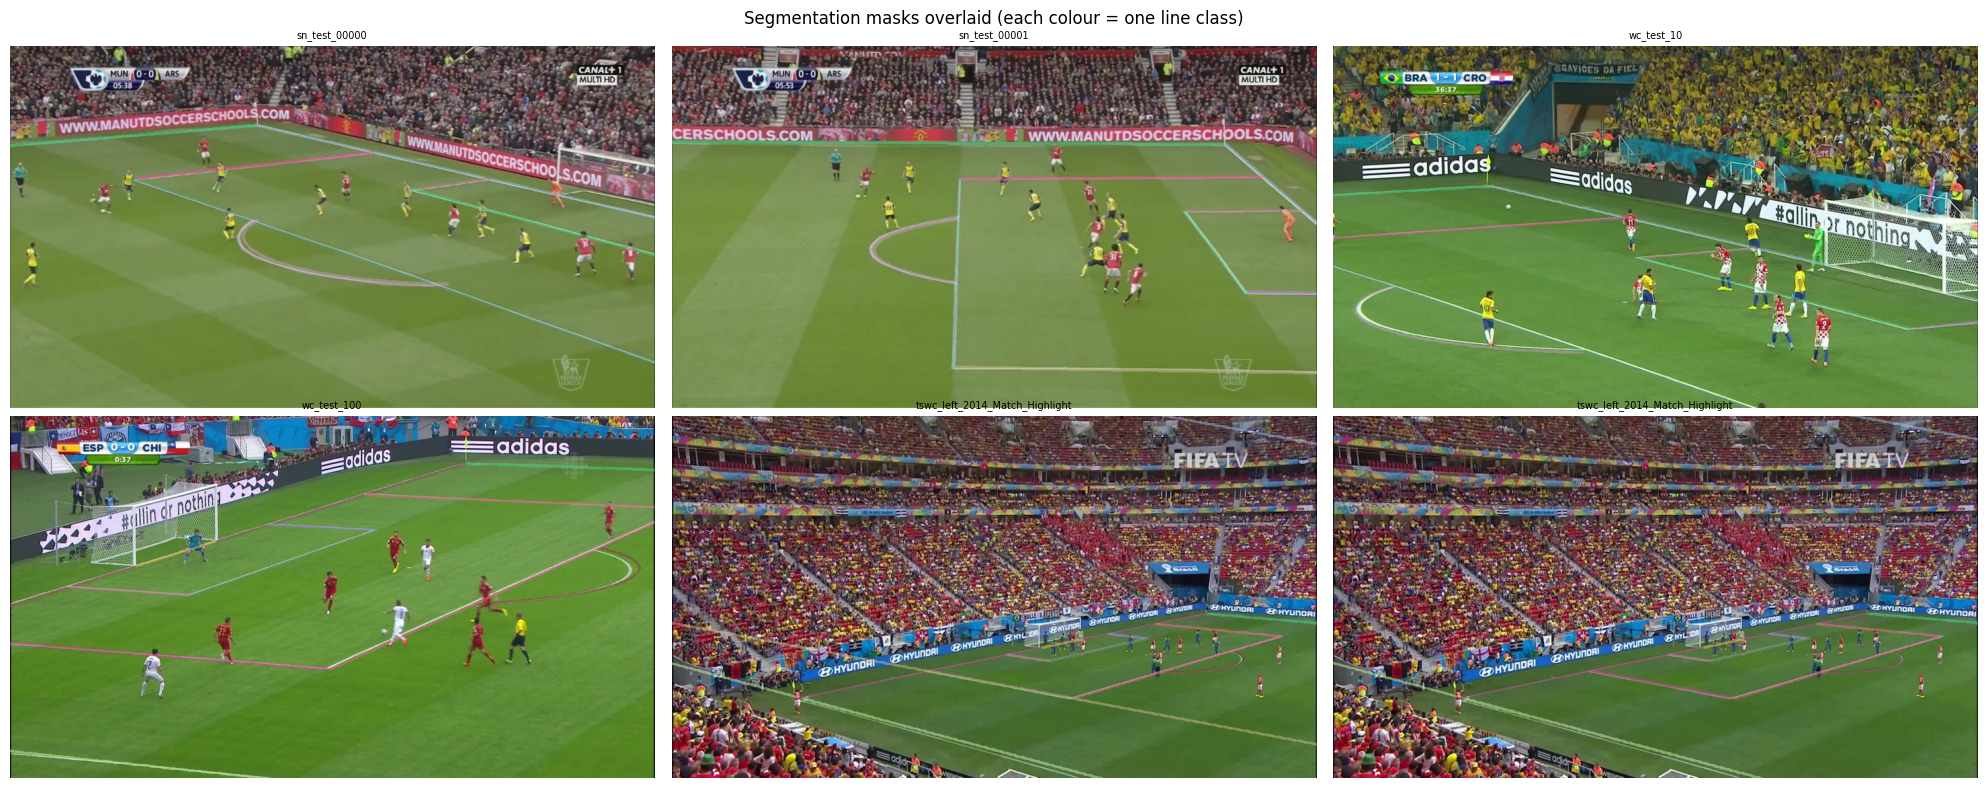

In [9]:
# Visual check: show 6 samples with mask overlays
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import cv2

SEG_ROOT = Path("datasets/pitch_seg")

sample_imgs = (sorted((SEG_ROOT / "images" / "train").glob("sn_*.jpg"))[:2]
             + sorted((SEG_ROOT / "images" / "train").glob("wc_*.jpg"))[:2]
             + sorted((SEG_ROOT / "images" / "train").glob("tswc_*.jpg"))[:2])

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
# Colour palette for 24 classes (0=black background)
palette = np.zeros((24, 3), dtype=np.uint8)
palette[1:]  = (np.random.RandomState(7).rand(23, 3) * 200 + 55).astype(np.uint8)

for ax, ip in zip(axes.flat, sample_imgs):
    img = np.array(Image.open(ip))
    mp = SEG_ROOT / "masks" / ip.parent.name / (ip.stem + ".png")
    mask = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
    overlay = img.copy()
    for cls_id in range(1, 24):
        m = mask == cls_id
        if m.any():
            overlay[m] = overlay[m] // 2 + palette[cls_id] // 2
    ax.imshow(overlay); ax.set_title(ip.stem[:30], fontsize=7); ax.axis("off")

plt.suptitle("Segmentation masks overlaid (each colour = one line class)")
plt.tight_layout(); plt.show()

## Train DeepLabV3+ (ResNet-50)

Run this on a GPU machine. Key design choices:
- **Inverse-frequency class weights** to handle the massive background/line imbalance
- **Cosine LR schedule** + early stopping on val mIoU
- **Augmentation:** horizontal flip, colour jitter, Gaussian noise

In [14]:
"""
Train DeepLabV3+ (ResNet-50) for pitch-line segmentation.
"""
import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
from pathlib import Path
import time

# ─── Config ──────────────────────────────────────────────────────────
SEG_ROOT     = Path("datasets/pitch_seg")
NUM_CLASSES  = 24
IMG_SIZE     = (960, 544)   # w, h — must be divisible by 32
BATCH_SIZE   = 32           # ↑ increase for H100 80GB (use 8 for ≤8GB VRAM)
NUM_WORKERS  = 8            # ↑ increase for many-core machines
NUM_EPOCHS   = 80
LR           = 2e-3         # scale up with larger batch
PATIENCE     = 15
USE_AMP      = True         # mixed-precision — ~2× speedup on Ampere/Hopper
SAVE_DIR     = Path("runs/seg")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
if device.type == "cuda":
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  VRAM: {vram_gb:.1f} GB")
    if vram_gb < 12:
        BATCH_SIZE = 8
        NUM_WORKERS = 4
        print(f"  -> Auto-reduced BATCH_SIZE={BATCH_SIZE}, NUM_WORKERS={NUM_WORKERS}")
    elif vram_gb < 24:
        BATCH_SIZE = 16
        print(f"  -> Auto-set BATCH_SIZE={BATCH_SIZE}")
    # H100/A100 80GB: BATCH_SIZE=32 is fine, could go to 64

# ─── Dataset ─────────────────────────────────────────────────────────
class PitchSegDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.img_dir  = root / "images" / split
        self.mask_dir = root / "masks"  / split
        self.items = sorted(self.img_dir.glob("*.jpg"))
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path  = self.items[idx]
        mask_path = self.mask_dir / (img_path.stem + ".png")
        img  = cv2.imread(str(img_path))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if self.transform:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]
        return img, mask.long()


train_tfm = A.Compose([
    A.Resize(IMG_SIZE[1], IMG_SIZE[0]),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.7),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Resize(IMG_SIZE[1], IMG_SIZE[0]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_ds = PitchSegDataset(SEG_ROOT, "train", train_tfm)
val_ds   = PitchSegDataset(SEG_ROOT, "val",   val_tfm)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                      persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      persistent_workers=True)

n_train_batches = len(train_dl)
print(f"Train: {len(train_ds)} ({n_train_batches} batches)  Val: {len(val_ds)}  Batch size: {BATCH_SIZE}")

# ─── Model ───────────────────────────────────────────────────────────
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)
model = model.to(device)
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

# ─── Class weights — up-weight line pixels (rare) vs background ─────
print("Computing class weights from training masks ...")
cls_counts = np.zeros(NUM_CLASSES, dtype=np.float64)
mask_files = sorted((SEG_ROOT / "masks" / "train").glob("*.png"))
step = max(1, len(mask_files) // 500)
for mf in mask_files[::step]:
    m = cv2.imread(str(mf), cv2.IMREAD_GRAYSCALE)
    for c in range(NUM_CLASSES):
        cls_counts[c] += (m == c).sum()
cls_counts = np.maximum(cls_counts, 1.0)
cls_freq = cls_counts / cls_counts.sum()
weights = 1.0 / cls_freq
weights = weights / weights.min()
weights = np.minimum(weights, 50.0)
weights[0] = 0.5
weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"  Class weights range: {weights.min().item():.1f} – {weights.max().item():.1f}")

criterion = nn.CrossEntropyLoss(weight=weights, ignore_index=255)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS,
                                                         eta_min=LR * 0.01)
scaler = GradScaler("cuda", enabled=USE_AMP)

# ─── Metrics ─────────────────────────────────────────────────────────
def compute_iou(pred, target, num_classes):
    ious = []
    for c in range(1, num_classes):  # skip background
        p = pred == c
        t = target == c
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union > 0:
            ious.append(inter / union)
    return np.mean(ious) if ious else 0.0

# ─── Training loop ───────────────────────────────────────────────────
best_miou = 0.0
patience_counter = 0
LOG_EVERY = max(1, n_train_batches // 5)  # ~5 progress updates per epoch

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()
    running_loss = 0.0

    for batch_idx, (imgs, masks) in enumerate(train_dl):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast("cuda", enabled=USE_AMP):
            logits = model(imgs)
            loss = criterion(logits, masks)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)

        if (batch_idx + 1) % LOG_EVERY == 0:
            pct = (batch_idx + 1) / n_train_batches * 100
            avg = running_loss / ((batch_idx + 1) * BATCH_SIZE)
            elapsed = time.time() - t0
            print(f"  Epoch {epoch} [{batch_idx+1}/{n_train_batches}] "
                  f"({pct:4.0f}%)  loss {avg:.4f}  {elapsed:.0f}s", flush=True)

    scheduler.step()
    train_loss = running_loss / len(train_ds)

    # ── Validation ──
    model.eval()
    val_loss = 0.0
    val_ious = []
    with torch.no_grad():
        for imgs, masks in val_dl:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with autocast("cuda", enabled=USE_AMP):
                logits = model(imgs)
                val_loss += criterion(logits, masks).item() * imgs.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            gt    = masks.cpu().numpy()
            for p, g in zip(preds, gt):
                val_ious.append(compute_iou(p, g, NUM_CLASSES))

    val_loss /= len(val_ds)
    val_miou  = np.mean(val_ious)
    lr_now    = optimizer.param_groups[0]["lr"]
    elapsed   = time.time() - t0

    improved = ""
    if val_miou > best_miou:
        best_miou = val_miou
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_DIR / "best_seg.pt")
        improved = "  ★ saved"
    else:
        patience_counter += 1

    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  "
          f"loss {train_loss:.4f} / {val_loss:.4f}  "
          f"mIoU {val_miou:.4f}  "
          f"lr {lr_now:.2e}  "
          f"{elapsed:.0f}s{improved}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (patience={PATIENCE})")
        break

print(f"\nBest val mIoU: {best_miou:.4f}")
print(f"Weights saved: {SAVE_DIR / 'best_seg.pt'}")

Device: cuda (NVIDIA RTX 1000 Ada Generation Laptop GPU)
  VRAM: 6.4 GB
  -> Auto-reduced BATCH_SIZE=8, NUM_WORKERS=4
Train: 21609 (2701 batches)  Val: 2700  Batch size: 8
Computing class weights from training masks ...
  Class weights range: 0.5 – 50.0


KeyboardInterrupt: 

## Video Inference

**Pipeline per frame:**
1. Run DeepLabV3+ → 24-class mask
2. For each predicted line class, sample 2D pixel points from the mask
3. Map each point to a 3D world coordinate via parametric position along the line/circle
4. Solve homography from the dense 2D↔3D correspondences (hundreds of points)
5. Draw pitch overlay + save camera params

In [8]:
"""
Segmentation-based video inference.
"""
import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2, json
import numpy as np
from pathlib import Path

# ─── Config ──────────────────────────────────────────────────────────
SEG_WEIGHTS  = "best_seg.pt"
VIDEO_IN     = "data/match_h264.mp4"
VIDEO_OUT    = "data/match_overlay_seg.mp4"
PARAMS_OUT   = "data/camera_params_seg.jsonl"
NUM_CLASSES  = 24
IMG_SIZE     = (960, 544)       # w, h — must match training
MIN_PTS      = 20               # min total correspondences for homography
MAX_PTS_PER_CLASS = 80          # max sampled points per line class
MAX_SECONDS  = 600

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── Line class names (same order as dataset builder) ────────────
LINE_CLASSES = [
    "Side line top",            # 1
    "Side line bottom",         # 2
    "Side line left",           # 3
    "Side line right",          # 4
    "Middle line",              # 5
    "Big rect. left top",       # 6
    "Big rect. left bottom",    # 7
    "Big rect. left main",      # 8
    "Big rect. right top",      # 9
    "Big rect. right bottom",   # 10
    "Big rect. right main",     # 11
    "Small rect. left top",     # 12
    "Small rect. left bottom",  # 13
    "Small rect. left main",    # 14
    "Small rect. right top",    # 15
    "Small rect. right bottom", # 16
    "Small rect. right main",   # 17
    "Circle central",           # 18
    "Circle left",              # 19
    "Circle right",             # 20
    "Goal left crossbar",       # 21
    "Goal left post left ",     # 22
    "Goal right crossbar",      # 23
]

# ─── Build 3D world geometry for each class ──────────────────────
pitch_model = SoccerPitch()
polylines_3d = pitch_model.sample_field_points(dist=0.1, dist_circles=0.08)

CLASS_WORLD_PTS = {}
CLASS_WORLD_XY  = {}

for cls_idx, cls_name in enumerate(LINE_CLASSES):
    cls_id = cls_idx + 1
    if cls_name in polylines_3d:
        pts = np.array(polylines_3d[cls_name], dtype=np.float64)
        CLASS_WORLD_PTS[cls_id] = pts
        CLASS_WORLD_XY[cls_id]  = pts[:, :2]

# ─── Load model ──────────────────────────────────────────────────────
model = smp.DeepLabV3Plus(
    encoder_name="resnet50", encoder_weights=None,
    in_channels=3, classes=NUM_CLASSES,
)
model.load_state_dict(torch.load(SEG_WEIGHTS, map_location=device, weights_only=True))
model = model.to(device).eval()

infer_tfm = A.Compose([
    A.Resize(IMG_SIZE[1], IMG_SIZE[0]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print(f"Model loaded from {SEG_WEIGHTS}")

# ─── Helper: extract correspondences from mask ────────────────────
def mask_to_correspondences(mask, frame_w, frame_h):
    mask_h, mask_w = mask.shape
    sx = frame_w / mask_w
    sy = frame_h / mask_h

    pts_2d_all, pts_3d_all = [], []

    for cls_id, world_xy in CLASS_WORLD_XY.items():
        ys, xs = np.where(mask == cls_id)
        if len(xs) < 3:
            continue

        if len(xs) > MAX_PTS_PER_CLASS:
            idx = np.random.choice(len(xs), MAX_PTS_PER_CLASS, replace=False)
            xs, ys = xs[idx], ys[idx]

        px = xs.astype(np.float64) * sx
        py = ys.astype(np.float64) * sy
        pts_2d_cls = np.column_stack([px, py])

        n_world = len(world_xy)
        if n_world < 2:
            continue

        # Compute the principal axis of the 2D points (PCA direction)
        centroid_2d = pts_2d_cls.mean(axis=0)
        centered = pts_2d_cls - centroid_2d

        if len(centered) > 1:
            cov = centered.T @ centered
            eigvals, eigvecs = np.linalg.eigh(cov)
            principal = eigvecs[:, -1]
        else:
            principal = np.array([1.0, 0.0])

        t_2d = centered @ principal
        t_min, t_max = t_2d.min(), t_2d.max()
        if t_max - t_min < 1e-3:
            continue
        t_norm = (t_2d - t_min) / (t_max - t_min)  # 0..1

        # Compute cumulative arc-length parameter for 3D polyline
        diffs_3d = np.diff(world_xy, axis=0)
        seg_lens = np.linalg.norm(diffs_3d, axis=1)
        cum_len  = np.concatenate([[0], np.cumsum(seg_lens)])
        total_len = cum_len[-1]
        if total_len < 1e-6:
            continue
        t_3d = cum_len / total_len  # 0..1 for each world point

        # For each 2D point, interpolate the 3D position
        for i in range(len(pts_2d_cls)):
            t = t_norm[i]
            j = np.searchsorted(t_3d, t, side="right") - 1
            j = np.clip(j, 0, n_world - 2)
            local_t = (t - t_3d[j]) / max(t_3d[j+1] - t_3d[j], 1e-9)
            local_t = np.clip(local_t, 0, 1)
            w3d = world_xy[j] * (1 - local_t) + world_xy[j+1] * local_t
            pts_2d_all.append(pts_2d_cls[i])
            pts_3d_all.append(w3d)

    if len(pts_2d_all) < MIN_PTS:
        return None, None

    return np.array(pts_2d_all, dtype=np.float32), np.array(pts_3d_all, dtype=np.float32)


# ─── Overlay drawing ─────────────────────────────────────────────────
GOAL_KEYS = {"Goal left crossbar", "Goal left post left ",
             "Goal left post right", "Goal right crossbar",
             "Goal right post left", "Goal right post right"}
ground_lines = {k: v for k, v in polylines_3d.items() if k not in GOAL_KEYS}


def draw_overlay(frame, H, frame_w, frame_h):
    for cls_name, pts in ground_lines.items():
        color = (0, 220, 255) if "Circle" in cls_name else (0, 220, 0)
        prev = None
        for pt in pts:
            p = H @ np.array([pt[0], pt[1], 1.0])
            if abs(p[2]) < 1e-6:
                prev = None; continue
            p /= p[2]
            px, py = int(p[0]), int(p[1])
            if prev is not None:
                ppx, ppy = prev
                if ((0 <= px < frame_w and 0 <= py < frame_h) or
                    (0 <= ppx < frame_w and 0 <= ppy < frame_h)):
                    cv2.line(frame, (ppx, ppy), (px, py), color, 2)
            prev = (px, py)
    return frame


# ─── Video loop ──────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_IN)
fps     = cap.get(cv2.CAP_PROP_FPS)
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if MAX_SECONDS:
    total = min(total, int(MAX_SECONDS * fps))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(VIDEO_OUT, fourcc, fps, (frame_w, frame_h))

print(f"Input:  {VIDEO_IN}  ({frame_w}x{frame_h} @ {fps:.1f} fps, {total} frames)")
print(f"Output: {VIDEO_OUT}")

frames_with_overlay = 0
pf = open(PARAMS_OUT, "w")

for fidx in range(total):
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    inp = infer_tfm(image=rgb)["image"].unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        logits = model(inp)
        mask = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    # Extract correspondences
    pts_2d, pts_3d = mask_to_correspondences(mask, frame_w, frame_h)

    H = None
    cam_dict = None

    if pts_2d is not None:
        H, hmask = cv2.findHomography(pts_3d, pts_2d, cv2.RANSAC, 8.0)
        if H is not None and hmask is not None and hmask.sum() >= 8:
            frame = draw_overlay(frame, H, frame_w, frame_h)

            cam = Camera(iwidth=frame_w, iheight=frame_h)
            if cam.from_homography(H):
                cam_dict = {
                    "frame": fidx,
                    "time_sec": round(fidx / fps, 3),
                    "homography": H.tolist(),
                    "position_m": cam.position.tolist(),
                    "focal_px": [cam.xfocal_length, cam.yfocal_length],
                    "n_correspondences": len(pts_2d),
                    "n_inliers": int(hmask.sum()),
                }
            frames_with_overlay += 1
        else:
            H = None

    if cam_dict is not None:
        pf.write(json.dumps(cam_dict) + "\n")

    writer.write(frame)

    if (fidx + 1) % 1000 == 0 or fidx == total - 1:
        pct = (fidx + 1) / total * 100
        print(f"  {fidx+1:>7}/{total}  ({pct:5.1f}%)  overlays: {frames_with_overlay}")

cap.release()
writer.release()
pf.close()

print(f"\n{'='*60}")
print(f"  Frames processed:    {total}")
print(f"  Frames with overlay: {frames_with_overlay}  ({frames_with_overlay/max(total,1)*100:.1f}%)")
print(f"  Overlay video:       {VIDEO_OUT}")
print(f"  Camera params:       {PARAMS_OUT}")

Model loaded from best_seg.pt
Input:  data/match_h264.mp4  (1920x1080 @ 25.0 fps, 15000 frames)
Output: data/match_overlay_seg.mp4
     1000/15000  (  6.7%)  overlays: 933
     2000/15000  ( 13.3%)  overlays: 1859
     3000/15000  ( 20.0%)  overlays: 2828
     4000/15000  ( 26.7%)  overlays: 3809
     5000/15000  ( 33.3%)  overlays: 4787
     6000/15000  ( 40.0%)  overlays: 5744
     7000/15000  ( 46.7%)  overlays: 6703
     8000/15000  ( 53.3%)  overlays: 7679
     9000/15000  ( 60.0%)  overlays: 8645
    10000/15000  ( 66.7%)  overlays: 9642
    11000/15000  ( 73.3%)  overlays: 10630
    12000/15000  ( 80.0%)  overlays: 11610
    13000/15000  ( 86.7%)  overlays: 12587
    14000/15000  ( 93.3%)  overlays: 13564
    15000/15000  (100.0%)  overlays: 14542

  Frames processed:    15000
  Frames with overlay: 14542  (96.9%)
  Overlay video:       data/match_overlay_seg.mp4
  Camera params:       data/camera_params_seg.jsonl
